In [1]:
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import os
import PcmPy as pcm
from Pcm import find_model
import globals as gl

plt.style.use('default')

Base directory found: /cifs/diedrichsen/data/SensoriMotorPrediction/
Base directory: /cifs/diedrichsen/data/SensoriMotorPrediction/


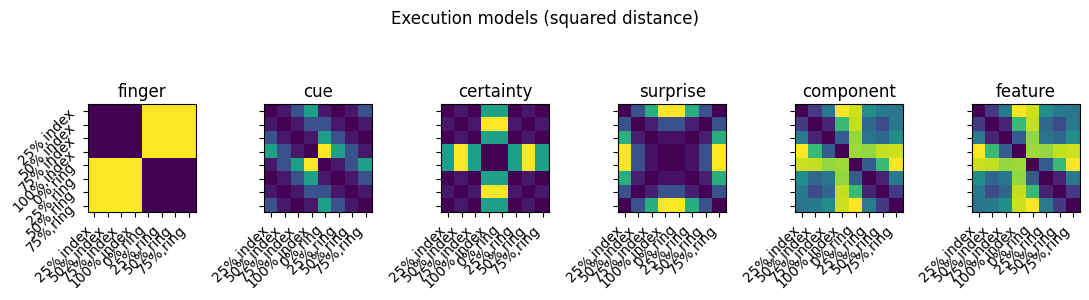

In [9]:
experiment = 'smp0'

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'rb')
M = pickle.load(f)

vmin, vmax=-4, 4

D, name = [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null'):
        D.append(pcm.G_to_dist(m.G))
        name.append(m.name)
    if isinstance(m, pcm.ComponentModel):
        D.append(pcm.G_to_dist(m.Gc.sum(axis=0)))
        name.append(m.name)
    if isinstance(m, pcm.FeatureModel):
        Ac = m.Ac.sum(axis=0)
        G = Ac @ Ac.T
        D.append(pcm.G_to_dist(G))
        name.append(m.name)

fig, axs = plt.subplots(1, len(D), sharex=True, sharey=True, figsize=(11, 3))

for ax, d, n in zip(axs, D, name ):
    # d = np.sign(d) * np.sqrt(np.abs(d))
    ax.imshow(d, )
    ax.set_title(n)

    ax.set_xticks(np.arange(8))
    ax.set_xticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=45, ha='right')
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=45, ha='right')

fig.suptitle('Execution models (squared distance)')
fig.tight_layout()

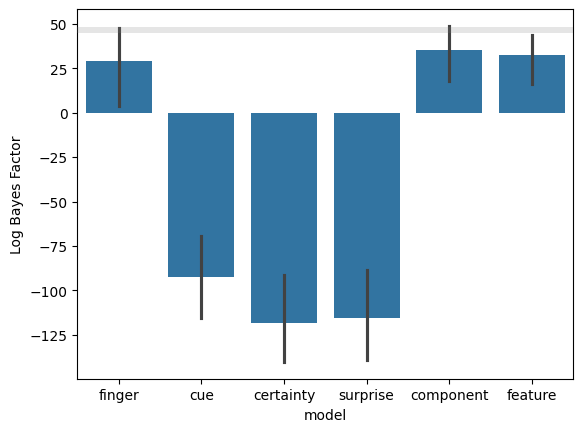

In [10]:
experiment = 'smp0'

T_cv = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_cv.emg.Vol.pkl'))
T_gr = pd.read_pickle(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'T_gr.emg.Vol.pkl'))

ax = pcm.model_plot(T_cv.likelihood,
                    null_model = 'null',
                    noise_ceiling= 'ceil',
                    upper_ceiling = T_gr.likelihood['ceil'])

# axs.legend(loc='upper center', ncol=1,bbox_to_anchor=(0.5, -0.1))

# axs.set_title('Marginal likelihood\nrelative to null model (EMG)')

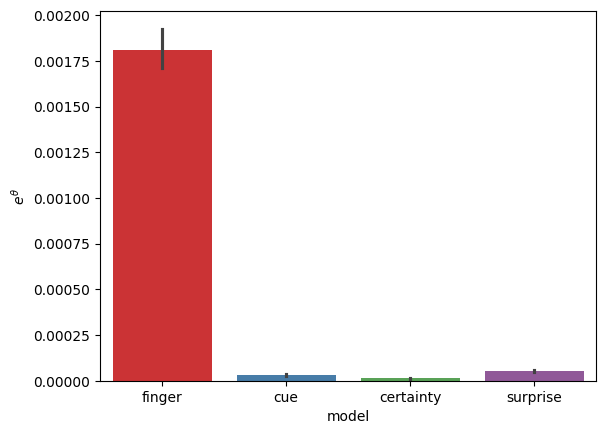

In [6]:
M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'component')
n_param = M.n_param
components = ['finger','cue','certainty', 'surprise']

theta = {
    'sn': [],
    'model': [],
    'theta': []
}

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.emg.Vol.pkl'), "rb")
theta_tmp = pickle.load(f)[idx]
theta_scaling = theta_tmp[n_param]

theta['theta'].extend((np.exp(theta_tmp[:n_param])).flatten())
theta['sn'].extend(np.tile(np.arange(theta_tmp[:n_param].shape[1]), M.n_param))
theta['model'].extend([mdl for mdl in components for _ in range(theta_tmp[:n_param].shape[1])])

theta = pd.DataFrame(theta)

fig, axs = plt.subplots()
fig.subplots_adjust(hspace=0.05)

sns.barplot(ax=axs, data=theta, x='model', y='theta', palette='Set1',)
# add_significant_patches_to_ml_rois(fig, axs, theta, width, 7, field='theta')

axs.set_ylabel(r"$e^{\theta}$")

plt.show()

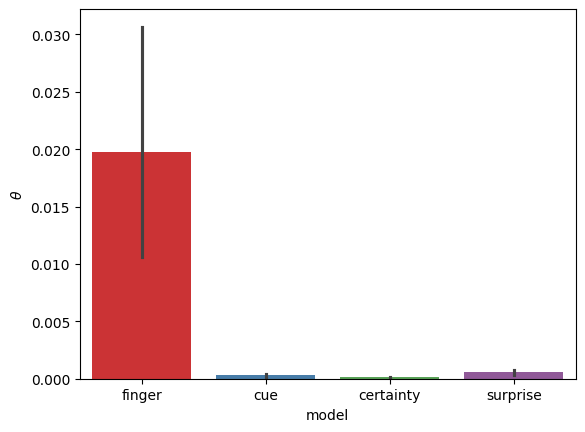

In [8]:
M, idx = find_model(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'M.emg.pkl'), 'feature')
n_param = M.n_param
features = ['finger','cue','certainty', 'surprise']

theta = {
    'sn': [],
    'model': [],
    'theta': []
}

f = open(os.path.join(gl.baseDir, experiment, gl.pcmDir, f'theta_cv.emg.Vol.pkl'), "rb")
theta_tmp = pickle.load(f)[idx]
theta_scaling = theta_tmp[n_param]

theta['theta'].extend((theta_tmp[:n_param]**2).flatten())
theta['sn'].extend(np.tile(np.arange(theta_tmp[:n_param].shape[1]), M.n_param))
theta['model'].extend([mdl for mdl in features for _ in range(theta_tmp[:n_param].shape[1])])

theta = pd.DataFrame(theta)

fig, axs = plt.subplots()
fig.subplots_adjust(hspace=0.05)

sns.barplot(ax=axs, data=theta, x='model', y='theta', palette='Set1',)
# add_significant_patches_to_ml_rois(fig, axs, theta, width, 7, field='theta')

axs.set_ylabel(r"$\theta$")

plt.show()